In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df = pd.read_excel('loan_data.xlsx')

In [3]:
print("no.of rows:",df.shape[0])

no.of rows: 38576


In [4]:
print("no.of columns:",df.shape[1])

no.of columns: 24


In [5]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  str           
 2   application_type       38576 non-null  str           
 3   emp_length             38576 non-null  str           
 4   emp_title              37138 non-null  str           
 5   grade                  38576 non-null  str           
 6   home_ownership         38576 non-null  str           
 7   issue_date             38576 non-null  datetime64[us]
 8   last_credit_pull_date  38576 non-null  datetime64[us]
 9   last_payment_date      38576 non-null  datetime64[us]
 10  loan_status            38576 non-null  str           
 11  next_payment_date      38576 non-null  datetime64[us]
 12  member_id              38576 non-null  int64         
 13  purpose     

In [7]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007,2021-06-08 13:36:34.193280,2021-06-26 09:52:08.909166,2021-07-26 20:42:20.605557,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### Total loan application


In [8]:
Total_loan_application = df['id'].count()
print("Total Loan Application:",Total_loan_application)

Total Loan Application: 38576


### MTD Total Loan Application

In [9]:
df['issue_date'] = pd.to_datetime(df['issue_date'])
latest_issue_date = df['issue_date'].max()  # ← add ()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
MTD_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)] 

MTD_loan_application = MTD_data['id'].count()

print("MTD Total Loan Application:",MTD_loan_application)

MTD Total Loan Application: 4314


### Total Funded amount

In [10]:
Total_Funded_amount = df['loan_amount'].sum()

total_funded_millions = Total_Funded_amount / 1000000
print("Total Funded Amount: ${:.2f}M".format(total_funded_millions))

Total Funded Amount: $435.76M


### MTD Total Funded amount

In [11]:
df['issue_date'] = pd.to_datetime(df['issue_date'])
latest_issue_date = df['issue_date'].max()  # ← add ()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
MTD_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)] 

MTD_funded_amount = MTD_data['loan_amount'].sum()

total_funded_millions = MTD_funded_amount / 1000000
print("MTD Total funded amount: ${:.2f}M".format(total_funded_millions))


MTD Total funded amount: $53.98M


### Total amount recieved

In [12]:
Total_amount_recieved = df['total_payment'].sum()

total_amount_recieved_millions = Total_amount_recieved / 1000000
print("Total Amount Recieved: ${:.2f}M".format(total_amount_recieved_millions))

Total Amount Recieved: $473.07M


### MTD Total amount recieved

In [13]:
df['issue_date'] = pd.to_datetime(df['issue_date'])
latest_issue_date = df['issue_date'].max()  # ← add ()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
MTD_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)] 

MTD_Total_amount_recieved = MTD_data['total_payment'].sum()

total_amount_recieved_millions = MTD_Total_amount_recieved / 1000000
print("MTD Total Amount Recieved: ${:.2f}M".format(total_amount_recieved_millions))


MTD Total Amount Recieved: $58.07M


### Average Interest Rate

In [14]:
avg_int_rate = df['int_rate'].mean()*100
print("Average Interest Rate:{:.2f}%".format(avg_int_rate))

Average Interest Rate:12.05%


### Average DTI

In [15]:
avg_dti = df['dti'].mean()*100
print("Average DTI:{:.2f}%".format(avg_dti))

Average DTI:13.33%


### Good Loan Metrics

In [16]:
good_loan = df[df['loan_status'].isin(["Fully Paid","Current"])]

Total_loan_application = df['id'].count()

good_loan_application = good_loan['id'].count()
good_loan_Total_Funded_amount = good_loan['loan_amount'].sum()
good_loan_Total_amount_recieved = good_loan['total_payment'].sum()


good_loan_total_funded_millions = good_loan_Total_Funded_amount / 1000000
good_loan_total_amount_recieved_millions = good_loan_Total_amount_recieved / 1000000

good_loan_percentage = (good_loan_application/Total_loan_application)*100


print("Good Loan Application:",good_loan_application)
print("Good Loan Total Funded Amount: ${:.2f}M".format(good_loan_total_funded_millions))
print("Good Loan Total Amount Recieved: ${:.2f}M".format(good_loan_total_amount_recieved_millions))
print("Good Loan Percantage:{:.2f}%".format(good_loan_percentage))

Good Loan Application: 33243
Good Loan Total Funded Amount: $370.22M
Good Loan Total Amount Recieved: $435.79M
Good Loan Percantage:86.18%


### Bad Loan Metrics

In [17]:
bad_loan = df[df['loan_status'].isin(["Charged Off"])]

Total_loan_application = df['id'].count()

bad_loan_application = bad_loan['id'].count()
bad_loan_Total_Funded_amount = bad_loan['loan_amount'].sum()
bad_loan_Total_amount_recieved = bad_loan['total_payment'].sum()


bad_loan_total_funded_millions = bad_loan_Total_Funded_amount / 1000000
bad_loan_total_amount_recieved_millions = bad_loan_Total_amount_recieved / 1000000

bad_loan_percentage = (bad_loan_application/Total_loan_application)*100


print("Bad Loan Application:",bad_loan_application)
print("Bad Loan Total Funded Amount: ${:.2f}M".format(bad_loan_total_funded_millions))
print("Bad Loan Total Amount Recieved: ${:.2f}M".format(bad_loan_total_amount_recieved_millions))
print("Bad Loan Percantage:{:.2f}%".format(bad_loan_percentage))

Bad Loan Application: 5333
Bad Loan Total Funded Amount: $65.53M
Bad Loan Total Amount Recieved: $37.28M
Bad Loan Percantage:13.82%


### Monthly Trends by Issue Date for Total Funded Amount

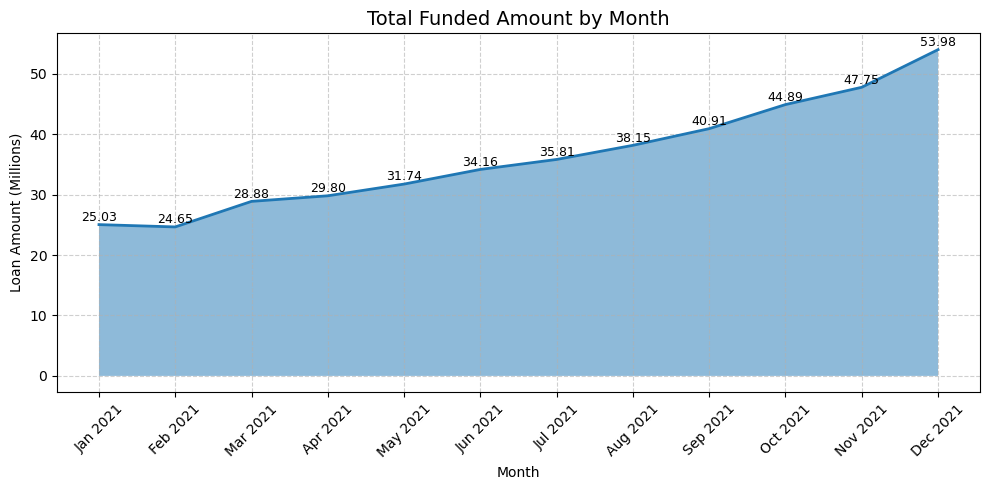

In [18]:
monthly_funded = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10,5))

plt.fill_between(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    alpha=0.5
)

plt.plot(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    linewidth=2
)

# Fix here
for i, row in monthly_funded.iterrows():
    plt.text(
        i,
        row['loan_amount_millions'] + 0.1,
        f"{row['loan_amount_millions']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Loan Amount (Millions)')

plt.xticks(
    ticks=range(len(monthly_funded)),
    labels=monthly_funded['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regional Analysis by State for total Funded Amount

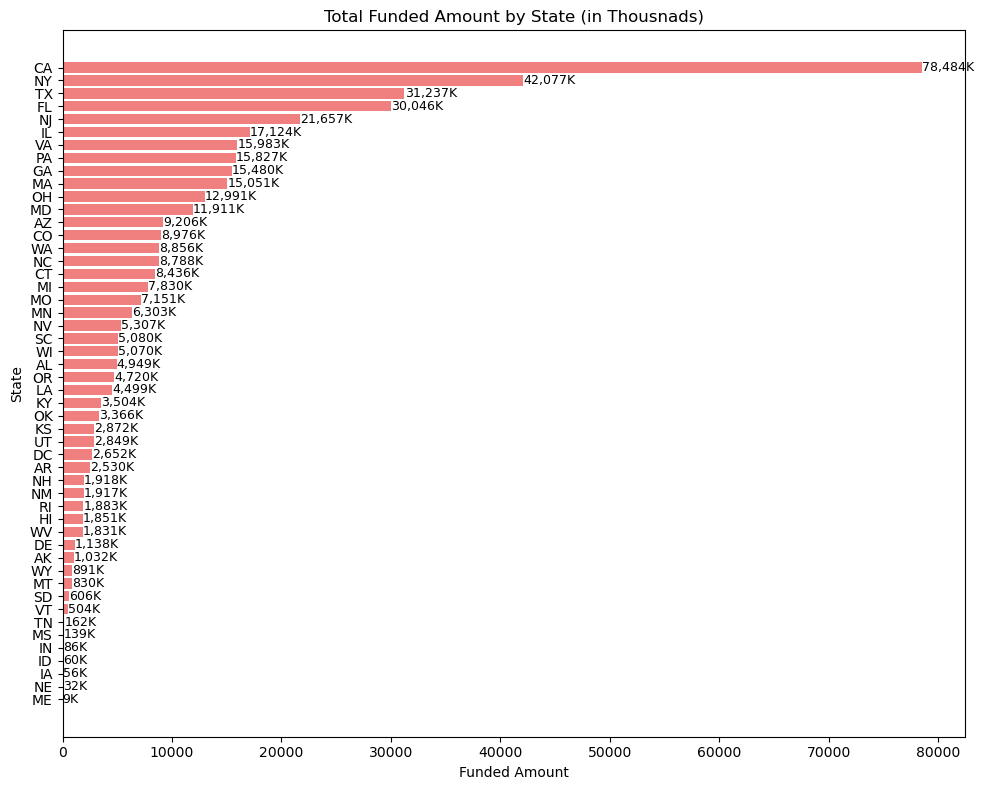

In [19]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(10,8))
bars = plt.barh(state_funding_thousands.index,state_funding_thousands.values,color = 'lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10,bar.get_y() + bar.get_height()/2,
             f"{width:,.0f}K",va='center',fontsize = 9)
    
plt.title('Total Funded Amount by State (in Thousnads)')
plt.xlabel('Funded Amount')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Loan Term Analsysis by Total Funded Amount

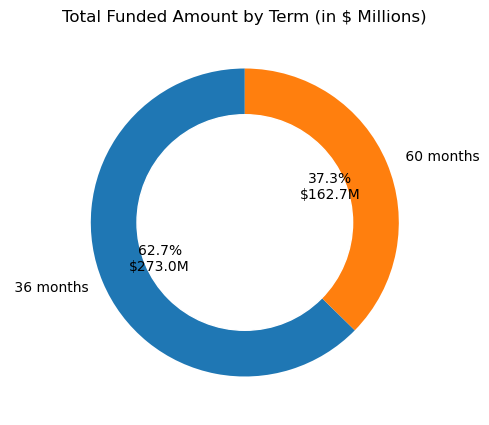

In [20]:
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize=(5,5))
plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p * term_funding_millions.sum() / 100:.1f}M",
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0,0), 0.70, color='white'))
plt.title("Total Funded Amount by Term (in $ Millions)")
plt.show()

### Employee Length By Total Funded Amount

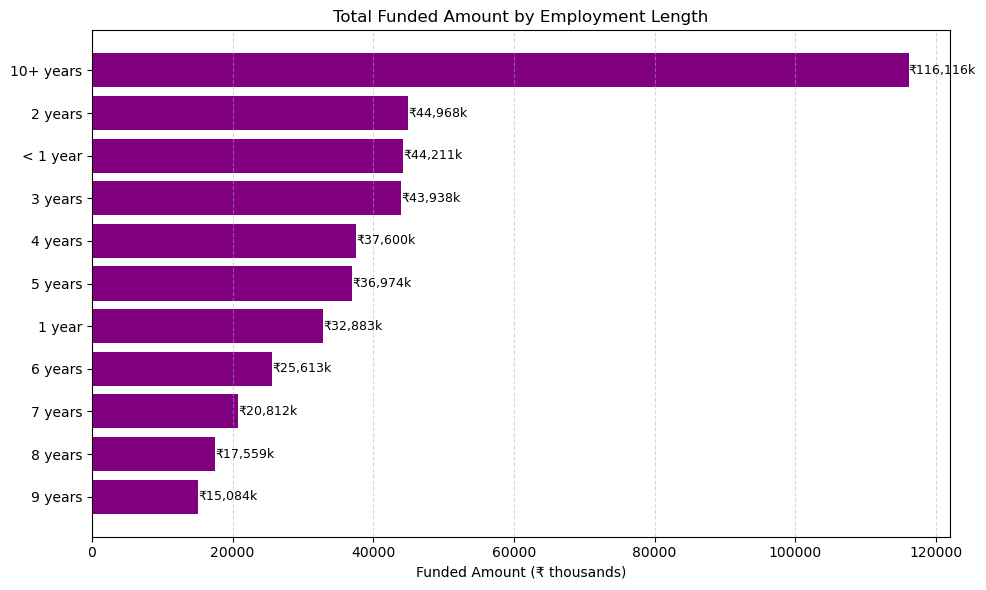

In [22]:
emp_funding_thousands = df.groupby('emp_length')['loan_amount'].sum().sort_values()/1000

plt.figure(figsize=(10,6))
bars = plt.barh(emp_funding_thousands.index,emp_funding_thousands,color='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,bar.get_y() + bar.get_height()/2,
             f"₹{width:,.0f}k",va = 'center',fontsize = 9)
    
plt.xlabel("Funded Amount (₹ thousands)")
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis ='x',linestyle = '--',alpha = 0.5)
plt.tight_layout()
plt.show()


### Loan Puropse by Total Funded Amount

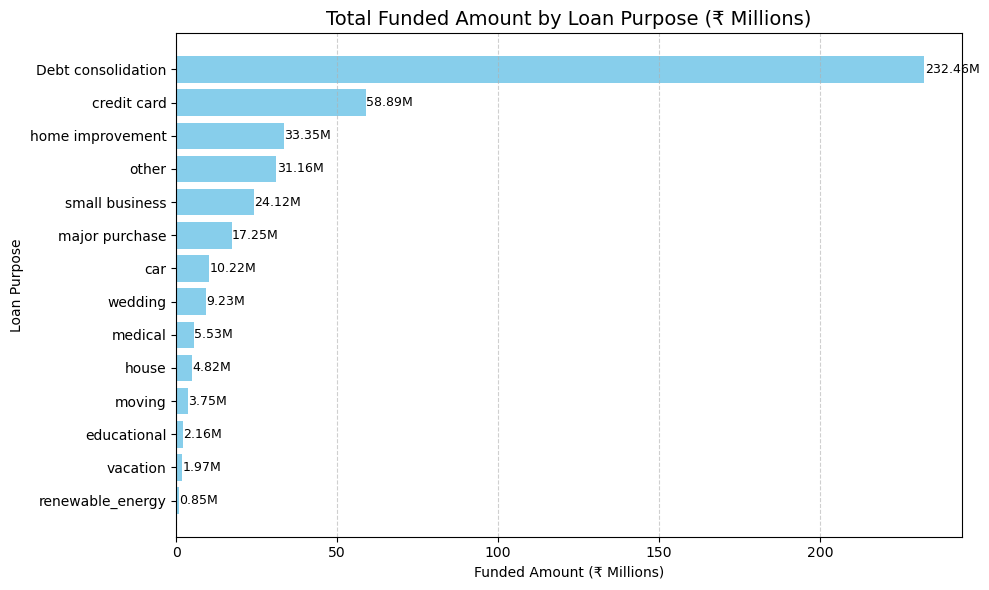

In [23]:
purpose_funding_millions = (df.groupby('purpose')['loan_amount']
                           .sum()
                           .sort_values()) / 1000000

plt.figure(figsize=(10, 6))
bars = plt.barh(purpose_funding_millions.index,
                purpose_funding_millions.values,
                color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1,
             bar.get_y() + bar.get_height()/2,
             f"{width:.2f}M",
             va='center',
             fontsize=9)

plt.title("Total Funded Amount by Loan Purpose (₹ Millions)", fontsize=14)
plt.xlabel("Funded Amount (₹ Millions)")
plt.ylabel("Loan Purpose")
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Home Ownership By Total Funded Amount



In [29]:
import sys
print(sys.executable)

c:\Users\risha\anaconda3\python.exe


In [31]:
import squarify
print("Working 👍")

Working 👍


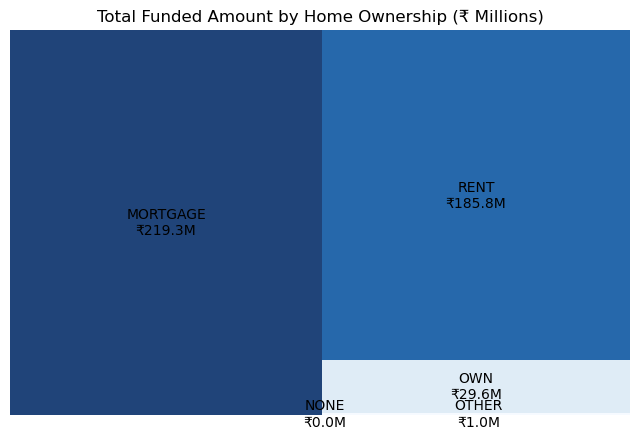

In [36]:

home_funding = df.groupby('home_ownership')['loan_amount'].sum()

plt.figure(figsize=(8,5))

squarify.plot(
    sizes=home_funding.values,
    label=[f"{i}\n₹{v/1_000_000:.1f}M" for i, v in zip(home_funding.index, home_funding.values)],
    color=plt.cm.Blues(home_funding.values / max(home_funding.values)),
    alpha=0.9
)

plt.axis('off')
plt.title("Total Funded Amount by Home Ownership (₹ Millions)")
plt.show()